# Incremental contribution of gammatone onset-8

For each subject, calculate:

`delta r = r(gammatone-8 + gammatone-on-8) - r(gammatone-8)`

Points above zero indicate improved held-out EEG prediction after adding the onset predictor. The black diamond and error bar show the group mean delta and its 95% confidence interval.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in (cwd, *cwd.parents)
        if (path / 'analysis' / 'trf_pipeline' / 'results').exists()
    ),
    None,
)
if repo_root is None:
    raise FileNotFoundError('Could not locate the Alice project root')

trf_pipeline_dir = repo_root / 'analysis' / 'trf_pipeline'
baseline_path = (
    trf_pipeline_dir
    / 'results'
    / 'by_predictor'
    / 'gammatone-8'
    / 'subject_results.csv'
)
combined_path = (
    trf_pipeline_dir
    / 'results'
    / 'by_multi_predictor'
    / 'gammatone-8-plus-gammatone-on-8'
    / 'subject_results.csv'
)
delta_table_path = (
    trf_pipeline_dir
    / 'results'
    / 'aggregate'
    / 'gammatone_8_plus_onset_8_delta.csv'
)
figure_path = repo_root / 'figures' / 'trf_gammatone_onset8_incremental_delta.png'

# False: paired primary-QC rows only; True: all successful finite paired TRFs.
INCLUDE_EXCLUDED = False

In [2]:
METRIC = 'tracking_r_mean'
BASELINE_TERM = 'gammatone-8'
COMBINED_TERM = 'gammatone-8 + gammatone-on-8'
CONTROLLED_COLUMNS = (
    'estimator',
    'raw',
    'epoch',
    'reference',
    'inv',
    'tstart',
    'tstop',
    'samplingrate',
    'filter_x',
)
REQUIRED_COLUMNS = {
    'subject',
    'predictor',
    'status',
    'finite_result',
    'include_trf_primary',
    'trf_exclusion_reason',
    METRIC,
    *CONTROLLED_COLUMNS,
}

baseline = pd.read_csv(baseline_path, keep_default_na=False)
combined = pd.read_csv(combined_path, keep_default_na=False)

for label, table, expected_term in (
    ('baseline', baseline, BASELINE_TERM),
    ('combined', combined, COMBINED_TERM),
):
    missing = REQUIRED_COLUMNS - set(table.columns)
    if missing:
        raise ValueError(f'{label} table is missing columns: {sorted(missing)}')
    terms = table['predictor'].unique().tolist()
    if terms != [expected_term]:
        raise ValueError(
            f'{label} table contains predictor terms {terms}; expected {expected_term!r}'
        )
    if table['subject'].duplicated().any():
        duplicates = table.loc[table['subject'].duplicated(), 'subject'].tolist()
        raise ValueError(f'{label} table contains duplicate subjects: {duplicates}')

if set(baseline['subject']) != set(combined['subject']):
    raise ValueError('Baseline and combined tables do not contain the same subjects')

for column in CONTROLLED_COLUMNS:
    baseline_values = baseline[column].unique().tolist()
    combined_values = combined[column].unique().tolist()
    if len(baseline_values) != 1 or baseline_values != combined_values:
        raise ValueError(
            f'Controlled setting {column!r} differs: '
            f'baseline={baseline_values}, combined={combined_values}'
        )

baseline_paired = baseline[[
    'subject',
    METRIC,
    'status',
    'finite_result',
    'include_trf_primary',
    'trf_exclusion_reason',
]].rename(columns={
    METRIC: 'tracking_r_baseline',
    'status': 'status_baseline',
    'finite_result': 'finite_baseline',
    'include_trf_primary': 'include_baseline',
    'trf_exclusion_reason': 'exclusion_baseline',
})
combined_paired = combined[[
    'subject',
    METRIC,
    'status',
    'finite_result',
    'include_trf_primary',
    'trf_exclusion_reason',
]].rename(columns={
    METRIC: 'tracking_r_combined',
    'status': 'status_combined',
    'finite_result': 'finite_combined',
    'include_trf_primary': 'include_combined',
    'trf_exclusion_reason': 'exclusion_combined',
})

paired = baseline_paired.merge(
    combined_paired,
    on='subject',
    how='inner',
    validate='one_to_one',
)
paired['delta_tracking_r'] = (
    paired['tracking_r_combined'] - paired['tracking_r_baseline']
)
paired['include_delta_primary'] = (
    paired['include_baseline'] & paired['include_combined']
)
paired.head()

,subject,tracking_r_baseline,status_baseline,finite_baseline,include_baseline,exclusion_baseline,tracking_r_combined,status_combined,finite_combined,include_combined,exclusion_combined,delta_tracking_r,include_delta_primary
0,sub-01,0.043644,ok,True,True,,0.048881,ok,True,True,,0.005237,True
1,sub-02,0.057938,ok,True,True,,0.056822,ok,True,True,,-0.001116,True
2,sub-03,0.042118,ok,True,True,,0.041565,ok,True,True,,-0.000553,True
3,sub-04,0.011066,ok,True,True,,0.014536,ok,True,True,,0.003470,True
4,sub-05,0.029306,ok,True,True,,0.031511,ok,True,True,,0.002204,True


In [3]:
if INCLUDE_EXCLUDED:
    plot_data = paired.loc[
        paired['status_baseline'].eq('ok')
        & paired['status_combined'].eq('ok')
        & paired['finite_baseline']
        & paired['finite_combined']
    ].copy()
else:
    plot_data = paired.loc[paired['include_delta_primary']].copy()

if plot_data.empty:
    raise ValueError('No paired rows remain after applying inclusion criteria')

delta_summary = pd.Series({
    'n_subjects': len(plot_data),
    'mean_delta_r': plot_data['delta_tracking_r'].mean(),
    'median_delta_r': plot_data['delta_tracking_r'].median(),
    'n_positive_delta': int((plot_data['delta_tracking_r'] > 0).sum()),
    'positive_delta_fraction': (plot_data['delta_tracking_r'] > 0).mean(),
    'n_negative_delta': int((plot_data['delta_tracking_r'] < 0).sum()),
    'negative_delta_fraction': (plot_data['delta_tracking_r'] < 0).mean(),
    'n_zero_delta': int((plot_data['delta_tracking_r'] == 0).sum()),
})
delta_summary

n_subjects                 47.000000
mean_delta_r                0.001465
median_delta_r              0.001187
n_positive_delta           33.000000
positive_delta_fraction     0.702128
dtype: float64

In [ ]:
negative_delta_subjects = (
    plot_data.loc[
        plot_data['delta_tracking_r'] < 0,
        [
            'subject',
            'tracking_r_baseline',
            'tracking_r_combined',
            'delta_tracking_r',
        ],
    ]
    .sort_values('delta_tracking_r')
    .reset_index(drop=True)
)
negative_delta_subjects.index = negative_delta_subjects.index + 1

negative_delta_subjects.style.format({
    'tracking_r_baseline': '{:.6f}',
    'tracking_r_combined': '{:.6f}',
    'delta_tracking_r': '{:.6f}',
}).set_caption(
    'Subjects with negative delta r, ordered from largest decrease to smallest'
)

In [4]:
delta_table_path.parent.mkdir(parents=True, exist_ok=True)
paired.to_csv(delta_table_path, index=False)
delta_table_path

PosixPath('/Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/analysis/trf_pipeline/results/aggregate/gammatone_8_plus_onset_8_delta.csv')

Saved paired delta table: /Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/analysis/trf_pipeline/results/aggregate/gammatone_8_plus_onset_8_delta.csv
Saved figure: /Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/figures/trf_gammatone_onset8_incremental_delta.png
Saved figure: /Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/figures/trf_gammatone_onset8_incremental_delta.pdf


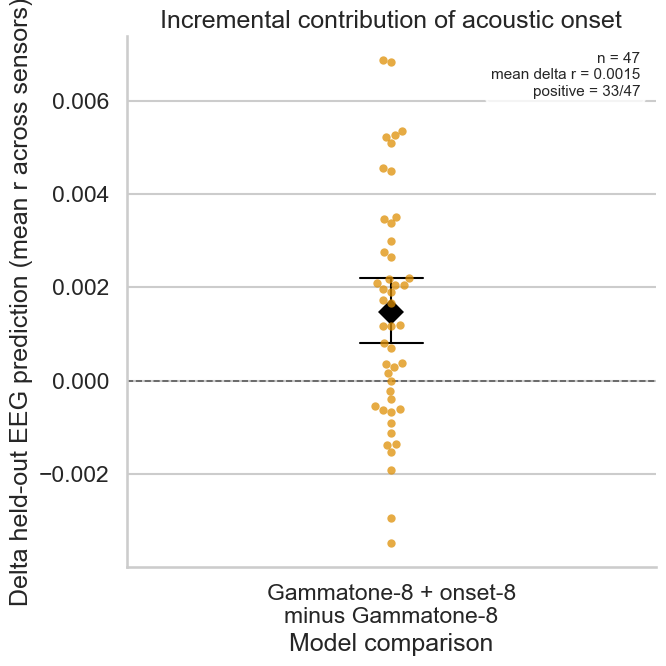

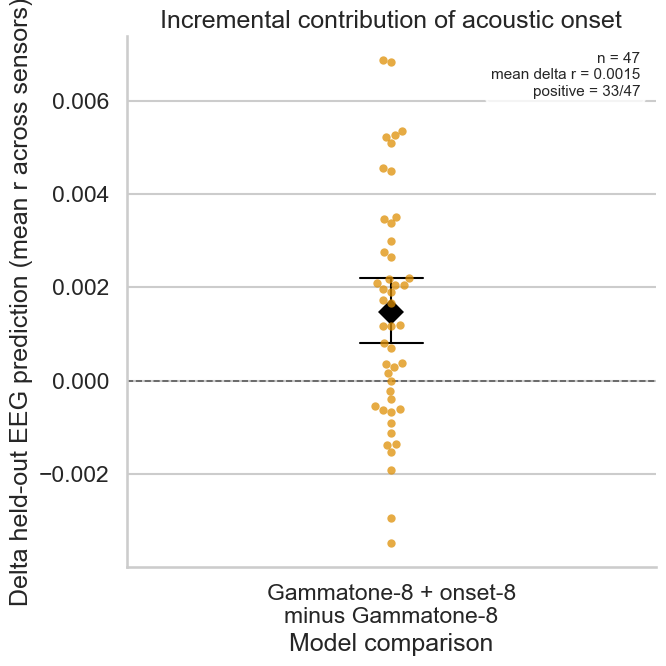

In [5]:
plot_data = plot_data.copy()
plot_data['comparison'] = 'Gammatone-8 + onset-8\nminus Gammatone-8'

sns.set_theme(style='whitegrid', context='talk')
figure, axis = plt.subplots(figsize=(7, 7))

sns.swarmplot(
    data=plot_data,
    x='comparison',
    y='delta_tracking_r',
    color=sns.color_palette('colorblind')[1],
    size=6,
    alpha=0.75,
    ax=axis,
)
sns.pointplot(
    data=plot_data,
    x='comparison',
    y='delta_tracking_r',
    estimator='mean',
    errorbar=('ci', 95),
    seed=0,
    color='black',
    markers='D',
    linestyles='none',
    capsize=0.12,
    err_kws={'linewidth': 1.5},
    ax=axis,
)

mean_delta = plot_data['delta_tracking_r'].mean()
n_positive = int((plot_data['delta_tracking_r'] > 0).sum())
n_subjects = len(plot_data)
axis.axhline(0, color='0.35', linestyle='--', linewidth=1.2)
axis.set_title('Incremental contribution of acoustic onset')
axis.set_xlabel('Model comparison')
axis.set_ylabel('Delta held-out EEG prediction (mean r across sensors)')
axis.text(
    0.97,
    0.97,
    f'n = {n_subjects}\nmean delta r = {mean_delta:.4f}\npositive = {n_positive}/{n_subjects}',
    transform=axis.transAxes,
    ha='right',
    va='top',
    fontsize=11,
    bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.8},
)
sns.despine(ax=axis)
figure.tight_layout()

figure_path.parent.mkdir(parents=True, exist_ok=True)
figure.savefig(figure_path, dpi=300, bbox_inches='tight')
figure.savefig(figure_path.with_suffix('.pdf'), bbox_inches='tight')
print(f'Saved paired delta table: {delta_table_path}')
print(f'Saved figure: {figure_path}')
print(f"Saved figure: {figure_path.with_suffix('.pdf')}")
figure